In [180]:
# Objective : Develop a Bayesian Marketing Mix Model using PyMC to quantify the impact of different marketing channels on sales while accounting for carryover (adstock) and diminishing returns (saturation).
# Use the model outputs to estimate channel-wise contribution and ROI, enabling data-driven budget allocation and optimization decisions.

**Load Data and Preprocessing**



In [181]:
# Load Data

import pandas as pd
df = pd.read_csv('/content/Conjura_Data.csv')
df.head()

,WEEK,Value,Units,Avg Price,Discount,GOOGLE_PAID_SEARCH_SPEND,GOOGLE_SHOPPING_SPEND,GOOGLE_PMAX_SPEND,GOOGLE_DISPLAY_SPEND,GOOGLE_VIDEO_SPEND,...,META_FACEBOOK_IMPRESSIONS,META_INSTAGRAM_IMPRESSIONS,META_OTHER_IMPRESSIONS,TIKTOK_IMPRESSIONS,DIRECT_CLICKS,BRANDED_SEARCH_CLICKS,ORGANIC_SEARCH_CLICKS,EMAIL_CLICKS,REFERRAL_CLICKS,ALL_OTHER_CLICKS
0,1/8/2022,3034056.53,7090,427.934631,1981713.20,2182.93,15657.87,0.0,0,0.0,...,0,0,0,0,1428,4095,6072,1464,3448,4522
1,1/15/2022,365868.64,2047,178.734069,26498.66,563.10,21103.44,0.0,0,0.0,...,0,0,0,0,1126,2540,5536,1762,2495,2895
2,1/22/2022,282952.29,1888,149.868798,11277.66,2830.29,12602.60,0.0,0,0.0,...,0,0,0,0,1066,1443,4978,838,1542,1917
3,1/29/2022,277077.18,1810,153.081315,14482.88,2404.95,10566.09,0.0,0,0.0,...,0,0,0,0,1014,1602,4229,820,1252,2028
4,2/5/2022,280658.36,1622,173.032281,17147.21,1588.12,9853.50,0.0,0,0.0,...,0,0,0,0,934,1436,4256,782,1285,1824


In [182]:
# Convert date

pd.to_datetime(df['WEEK'])



,WEEK
0,2022-01-08
1,2022-01-15
2,2022-01-22
3,2022-01-29
4,2022-02-05
...,...
99,2023-12-02
100,2023-12-09
101,2023-12-16
102,2023-12-23


In [183]:
# Set Target Variable
y = df['Value'].values

# Set Media Varibles
media_cols = [
    'GOOGLE_PAID_SEARCH_IMPRESSIONS',
    'GOOGLE_SHOPPING_IMPRESSIONS',
    'GOOGLE_PMAX_IMPRESSIONS',
    'GOOGLE_DISPLAY_IMPRESSIONS',
    'GOOGLE_VIDEO_IMPRESSIONS',
    'META_FACEBOOK_IMPRESSIONS',
    'META_INSTAGRAM_IMPRESSIONS',
    'META_OTHER_IMPRESSIONS',
    'TIKTOK_IMPRESSIONS']

X_media = df[media_cols].values

# Set Control Variables

control_cols = [
    'Avg Price',
    'Discount',   # promo variable
    'DIRECT_CLICKS',
    'BRANDED_SEARCH_CLICKS',
    'ORGANIC_SEARCH_CLICKS',
    'EMAIL_CLICKS',
    'REFERRAL_CLICKS',
    'ALL_OTHER_CLICKS']

X_ctrl = df[control_cols].values

# Scale variables

from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_media_scaled = scaler.fit_transform(X_media)
X_ctrl_scaled = scaler.fit_transform(X_ctrl)
y_scaled = scaler.fit_transform(y.reshape(-1, 1)) .flatten()   # reshape y from 1D (n,) to 2D (n,1) as StandardScaler expects 2D input


print("y_scaled:", y_scaled.shape)
print("X_media_sat:", X_media_sat.shape)
print("X_ctrl_scaled:", X_ctrl_scaled.shape)


y_scaled: (104,)
X_media_sat: (104, 9)
X_ctrl_scaled: (104, 8)


**Adstock Transformation**

In [184]:
# define adstock

import numpy as np

def adstock(x, theta):              # Adstock_t = x_t + θ * Adstock_{t-1}
    result = np.zeros_like(x)
    result[0] = x[0]

    for t in range(1, len(x)):
        result[t] = x[t] + theta * result[t-1]

    return result

# applying adstock to media

theta = 0.5  # initial assumption

X_media_ads = np.zeros_like(X_media_scaled)

for i in range(X_media_scaled.shape[1]):
    X_media_ads[:, i] = adstock(X_media_scaled[:, i], theta)

# check shape

X_media_ads.shape == X_media_scaled.shape

True

**Saturation Modeling**

In [185]:
# implement hill function
# f(x) = x^α / (x^α + γ^α)
# <1 : slow growth
# =1 : moderate growth
# >1 : S-Shaped curve


def hill_function(x, alpha=1.5, gamma=1):
    x = np.maximum(x, 0)   #  Remove negative values
    return (x**alpha) / (x**alpha + gamma**alpha + 1e-6)


# apply saturation on adstocked media

X_media_sat = hill_function(X_media_ads)

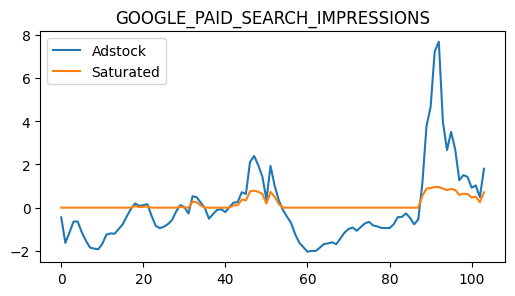

In [186]:
# Visual check

import matplotlib.pyplot as plt

plt.figure(figsize=(6,3))

plt.plot(X_media_ads[:,0], label='Adstock')
plt.plot(X_media_sat[:,0], label='Saturated')

plt.legend()
plt.title(media_cols[0])
plt.show()

***PyMC Model Specification (Bayesian MMM)***

In [187]:
import pymc as pm
import numpy as np

# ✅ Ensure everything is numpy
X_media_sat = np.array(X_media_sat)
X_ctrl_scaled = np.array(X_ctrl_scaled)
y_scaled = np.array(y_scaled).flatten()

# ✅ Define dimensions
n_media = X_media_sat.shape[1]
n_ctrl = X_ctrl_scaled.shape[1]

# ✅ Build model
with pm.Model() as mmm:

    # Intercept (baseline sales)
    intercept = pm.Normal("intercept", mu=0, sigma=1)

    # Media coefficients (positive constraint)
    beta_media = pm.HalfNormal("beta_media", sigma=1, shape=n_media)

    # Control coefficients (can be positive or negative)
    beta_ctrl = pm.Normal("beta_ctrl", mu=0, sigma=1, shape=n_ctrl)

    # Noise
    sigma = pm.HalfNormal("sigma", sigma=1)

    mu = (
        intercept
        + pm.math.sum(X_media_sat * beta_media, axis=1)
        + pm.math.sum(X_ctrl_scaled * beta_ctrl, axis=1)
    )

    # 🔹 Likelihood
    y_obs = pm.Normal("y_obs", mu=mu, sigma=sigma, observed=y_scaled)

**Sampling**


In [188]:
# Sampling : Drawing from posterior distributions
# In classical Regression: You get ONE value for each coefficient (β)
# In Bayesian : You get a DISTRIBUTION of values for each β

# What happens internally?
# NUTS (No-U-Turn Sampler)
# A form of Hamiltonian Monte Carlo

# Starts with random parameters
# Generates predictions
# Compares with actual data
# Adjusts parameters
# Repeats thousands of times

#  draws=2000: Final posterior samples per chain = 2000
#  tune=2000 : Warm-up phase (NOT used in final results)
#  Runs 4 independent processes
# how cautious the sampler is ( 0.8 : Faster but risky, 0.9: Stable, 0.95: slower and safer)

with mmm:
    trace = pm.sample(
        draws=2000,
        tune=2000,
        chains=4,
        target_accept=0.9,
        random_seed=42,
        progressbar=True,    # hows live progress
        cores=4              # parallel execution
    )




Output()

**Model Diagnostics**

In [189]:
# R-hat (convergence metric): r_hat ≈ 1.00 GOOD (To evaluate whether an algorithm has successfully converged)
# ESS (Effective Sample Size): > 200 good, > 500 very good
# Mean values (sanity check) :

import arviz as az
az.summary(trace)


,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
beta_ctrl[0],0.263,0.055,0.159,0.366,0.001,0.001,6806.0,5778.0,1.0
beta_ctrl[1],0.538,0.044,0.454,0.618,0.000,0.000,7632.0,6295.0,1.0
beta_ctrl[2],0.074,0.085,-0.081,0.238,0.001,0.001,5313.0,5672.0,1.0
beta_ctrl[3],0.224,0.070,0.092,0.355,0.001,0.001,7668.0,5812.0,1.0
beta_ctrl[4],-0.474,0.139,-0.724,-0.204,0.002,0.001,4995.0,5334.0,1.0
beta_ctrl[5],0.252,0.063,0.133,0.370,0.001,0.001,9463.0,5679.0,1.0
beta_ctrl[6],0.265,0.126,0.028,0.497,0.002,0.001,6024.0,5863.0,1.0
beta_ctrl[7],0.116,0.066,-0.009,0.237,0.001,0.001,6172.0,5789.0,1.0
beta_media[0],0.336,0.155,0.045,0.614,0.002,0.002,4198.0,3118.0,1.0
beta_media[1],0.194,0.098,0.010,0.364,0.001,0.001,4771.0,2622.0,1.0


array([[<Axes: title={'center': 'intercept'}>,
        <Axes: title={'center': 'intercept'}>],
       [<Axes: title={'center': 'beta_media'}>,
        <Axes: title={'center': 'beta_media'}>],
       [<Axes: title={'center': 'beta_ctrl'}>,
        <Axes: title={'center': 'beta_ctrl'}>]], dtype=object)

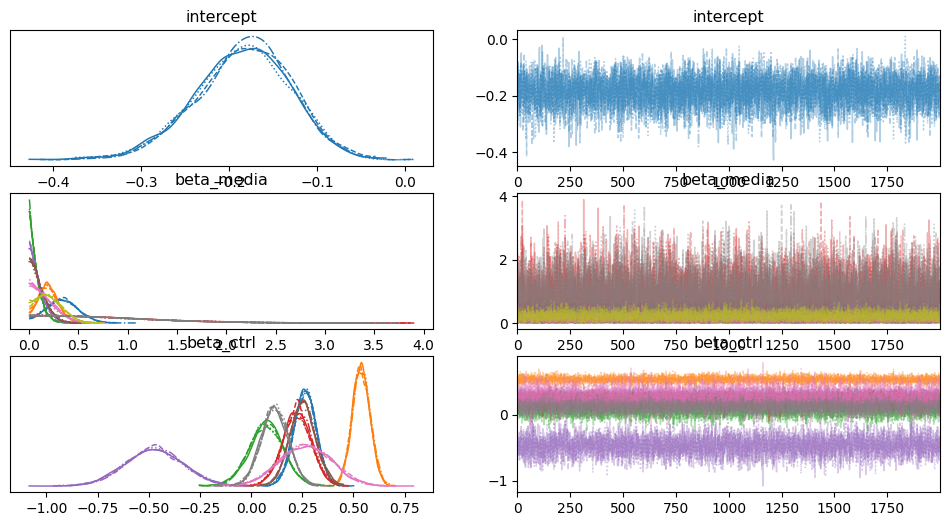

In [190]:
# trace plots
az.plot_trace(trace, var_names=["intercept", "beta_media", "beta_ctrl"])

# **Contribution Calculation**

In [191]:
# Extract posterior means
beta_media_mean = trace.posterior['beta_media'].mean(dim=('chain','draw')).values

# Compute contributions
media_contribution = X_media_sat * beta_media_mean

contribution_df = pd.DataFrame(media_contribution, columns=media_cols)

# Total contribution per channel
channel_contribution = contribution_df.sum().sort_values(ascending=False)
print(channel_contribution)


GOOGLE_PAID_SEARCH_IMPRESSIONS    5.965988
GOOGLE_SHOPPING_IMPRESSIONS       5.199153
META_FACEBOOK_IMPRESSIONS         3.223596
GOOGLE_PMAX_IMPRESSIONS           1.815448
TIKTOK_IMPRESSIONS                1.462646
META_INSTAGRAM_IMPRESSIONS        1.053910
GOOGLE_VIDEO_IMPRESSIONS          0.445123
GOOGLE_DISPLAY_IMPRESSIONS        0.000000
META_OTHER_IMPRESSIONS            0.000000
dtype: float64


**Model Validation**

In [192]:
# Train test split

split_idx = int(0.8 * len(df))

# Train
X_media_train = X_media_sat[:split_idx]
X_ctrl_train = X_ctrl_scaled[:split_idx]
y_train = y_scaled[:split_idx]

# Test
X_media_test = X_media_sat[split_idx:]
X_ctrl_test = X_ctrl_scaled[split_idx:]
y_test = y_scaled[split_idx:]

In [193]:
# Rebuild model on train data

with pm.Model() as mmm_train:

    intercept = pm.Normal("intercept", mu=0, sigma=1)

    beta_media = pm.HalfNormal("beta_media", sigma=1, shape=n_media)
    beta_ctrl = pm.Normal("beta_ctrl", mu=0, sigma=1, shape=n_ctrl)

    sigma = pm.HalfNormal("sigma", sigma=1)

    mu = (
        intercept
        + pm.math.sum(X_media_train * beta_media, axis=1)
        + pm.math.sum(X_ctrl_train * beta_ctrl, axis=1)
    )

    y_obs = pm.Normal("y_obs", mu=mu, sigma=sigma, observed=y_train)

In [194]:
# train model

with mmm_train:
    trace_train = pm.sample(
        draws=1500,
        tune=1500,
        chains=4,
        target_accept=0.9,
        random_seed=42)



Output()

In [195]:
# Get posterior means (for prediction)
beta_media_mean = trace_train.posterior['beta_media'].mean(dim=('chain','draw')).values
beta_ctrl_mean = trace_train.posterior['beta_ctrl'].mean(dim=('chain','draw')).values
intercept_mean = trace_train.posterior['intercept'].mean().values

In [196]:
# Predict on TEST data

y_pred_test = (
    intercept_mean
    + np.sum(X_media_test * beta_media_mean, axis=1)
    + np.sum(X_ctrl_test * beta_ctrl_mean, axis=1)
)

**Evaluation Metrics**

In [197]:
import numpy as np
from sklearn.metrics import r2_score, mean_absolute_percentage_error

# R² (goodness of fit)
r2 = r2_score(y_test, y_pred_test)

# MAPE (%)
mape = mean_absolute_percentage_error(y_test, y_pred_test) * 100

# RMSE
rmse = np.sqrt(np.mean((y_test - y_pred_test) ** 2))

print(f"R²: {r2:.4f}")
print(f"MAPE: {mape:.2f}%")   # less interpretable on scaled data
print(f"RMSE: {rmse:.4f}")


R²: 0.6619
MAPE: 155.74%
RMSE: 0.5882


In [198]:
# Durbin Watson

from statsmodels.stats.stattools import durbin_watson

residuals = y_test - y_pred_test

dw = durbin_watson(residuals)

print(f"Durbin-Watson: {dw:.3f}")

Durbin-Watson: 0.830


**Actual VS Predicted**

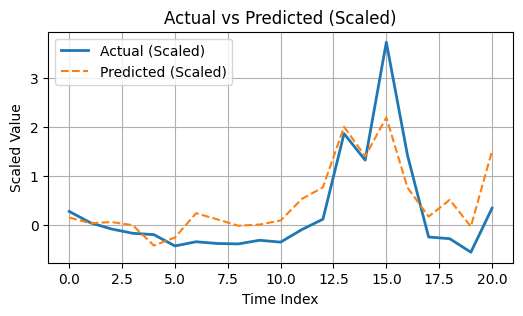

In [199]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,3))

plt.plot(y_test, label="Actual (Scaled)", linewidth=2)
plt.plot(y_pred_test, label="Predicted (Scaled)", linestyle="--")

plt.title("Actual vs Predicted (Scaled)")
plt.xlabel("Time Index")
plt.ylabel("Scaled Value")

plt.legend()
plt.grid(True)

plt.show()

**Deliverables Calculations**

In [207]:
# Convert scaled contribution to real value

y_std = y.std()

media_contribution_real = media_contribution * y_std

# Convert to DataFrame
contribution_df_real = pd.DataFrame(
    media_contribution_real,
    columns=media_cols
)

# Incremental value
incremental_value = contribution_df_real.sum()

print("Incremental Value (by channel):\n")
print(incremental_value.sort_values(ascending=False))


# Effectiveness
effectiveness = incremental_value / incremental_value.sum()

print("Effectiveness (% contribution):\n")
print(effectiveness.sort_values(ascending=False))

print("\nTotal Effectiveness:", effectiveness.sum())


Incremental Value (by channel):

GOOGLE_PAID_SEARCH_IMPRESSIONS    2.248767e+06
GOOGLE_SHOPPING_IMPRESSIONS       1.959723e+06
META_FACEBOOK_IMPRESSIONS         1.215074e+06
GOOGLE_PMAX_IMPRESSIONS           6.842991e+05
TIKTOK_IMPRESSIONS                5.513167e+05
META_INSTAGRAM_IMPRESSIONS        3.972514e+05
GOOGLE_VIDEO_IMPRESSIONS          1.677808e+05
GOOGLE_DISPLAY_IMPRESSIONS        0.000000e+00
META_OTHER_IMPRESSIONS            0.000000e+00
dtype: float64
Effectiveness (% contribution):

GOOGLE_PAID_SEARCH_IMPRESSIONS    0.311282
GOOGLE_SHOPPING_IMPRESSIONS       0.271272
META_FACEBOOK_IMPRESSIONS         0.168195
GOOGLE_PMAX_IMPRESSIONS           0.094723
TIKTOK_IMPRESSIONS                0.076315
META_INSTAGRAM_IMPRESSIONS        0.054989
GOOGLE_VIDEO_IMPRESSIONS          0.023225
GOOGLE_DISPLAY_IMPRESSIONS        0.000000
META_OTHER_IMPRESSIONS            0.000000
dtype: float64

Total Effectiveness: 0.9999999999999999


**Response curves**

In [210]:
def response_curve(x, beta, alpha=1.5, gamma=1):
    x = np.maximum(x, 0)
    return beta * (x**alpha / (x**alpha + gamma**alpha + 1e-6))

import numpy as np
import matplotlib.pyplot as plt

# Pick channel
channel = 'META_FACEBOOK_IMPRESSIONS'
idx = media_cols.index(channel)

# Range of input (simulate more spend)
x_range = np.linspace(
    X_media_ads[:, idx].min(),
    X_media_ads[:, idx].max() * 2,
    100
)

# Generate response
beta = beta_media_mean[idx]
response = response_curve(x_range, beta)


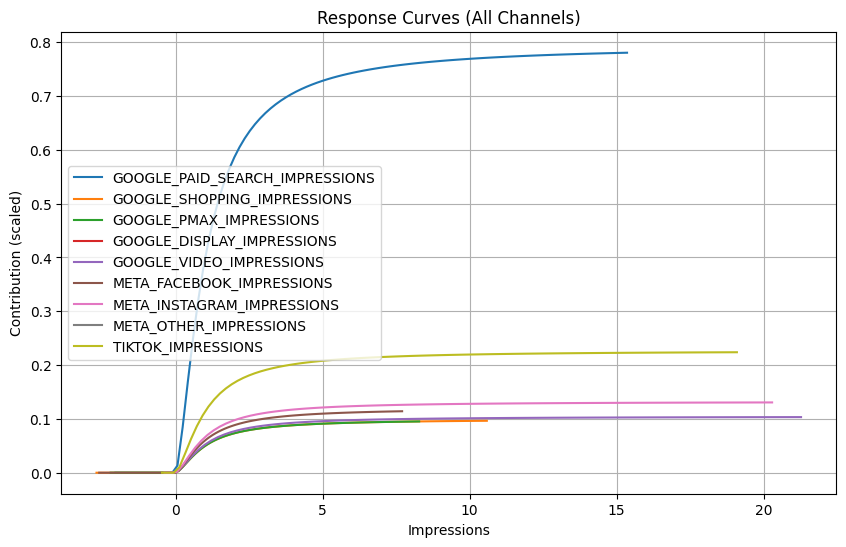

In [209]:
# Plot MULTIPLE channels
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

for i, col in enumerate(media_cols):
    beta = beta_media_mean[i]

    x_range = np.linspace(
        X_media_ads[:, i].min(),
        X_media_ads[:, i].max() * 2,
        100
    )

    response = response_curve(x_range, beta)

    plt.plot(x_range, response, label=col)

plt.legend()
plt.title("Response Curves (All Channels)")
plt.xlabel("Impressions")
plt.ylabel("Contribution (scaled)")
plt.grid(True)

plt.show()


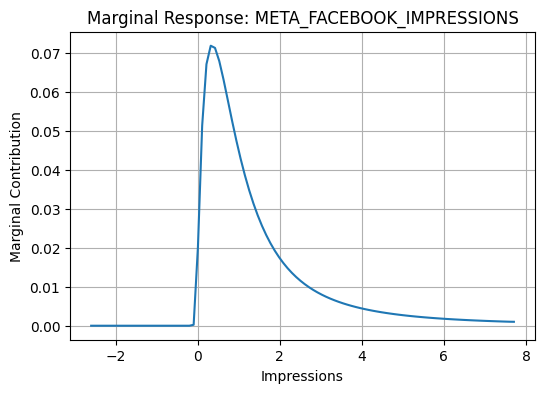

In [211]:
# Marginal Curve
marginal = np.gradient(response, x_range)

plt.figure(figsize=(6,4))
plt.plot(x_range, marginal)

plt.title(f"Marginal Response: {channel}")
plt.xlabel("Impressions")
plt.ylabel("Marginal Contribution")
plt.grid(True)

plt.show()

**52-WEEK FORECAST**